# Configuration and Load Data

In [13]:
import sys
print(sys.executable)

E:\Anaconda\python.exe


In [14]:
import os
import time
import numpy as np
import pandas as pd

from pathlib import Path
REPO_ROOT = Path.cwd().parent.parent
DATA_PROCESSED = REPO_ROOT / "data" / "processed"

TRAIN_PATH = DATA_PROCESSED / "train_normalized.parquet"
TEST_PATH  = DATA_PROCESSED / "test_normalized.parquet"

# Column names (keep consistent with your pipeline)
SEQ_COL   = "sequence_id"
LABEL_COL = "gesture"

# Random seed
SEED = 42

# FFT parameters
K_FREQ = 32

# Fixed TOF sequence length (CPU-friendly)
MAX_LEN = 48

# Training parameters
BATCH_SIZE = 64
EPOCHS = 20

# BFRB labels (positive class for Binary F1)
BFRB_LABELS = [
    "Above ear - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Neck - pinch skin",
    "Neck - scratch",
    "Cheek - pinch skin"
]
bfrb_set = set(BFRB_LABELS)

print("Repo root:", REPO_ROOT)
print("Train parquet:", TRAIN_PATH)
print("Test parquet :", TEST_PATH)

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

if LABEL_COL not in train_df.columns:
    if "behavior" in train_df.columns:
        LABEL_COL = "behavior"
    else:
        raise KeyError(f"Cannot find label column. Expected 'gesture' or 'behavior'. Columns: {list(train_df.columns)[:30]} ...")

# merge for convenience (many later cells expect a single df)
df = pd.concat([train_df, test_df], ignore_index=True)

print("Train rows:", train_df.shape, "unique sequences:", train_df[SEQ_COL].nunique())
print("Test  rows:", test_df.shape,  "unique sequences:", test_df[SEQ_COL].nunique())
print("All   rows:", df.shape,       "unique sequences:", df[SEQ_COL].nunique())


Repo root: E:\A1_last_version
Train parquet: E:\A1_last_version\data\processed\train_normalized.parquet
Test parquet : E:\A1_last_version\data\processed\test_normalized.parquet
Train rows: (419215, 341) unique sequences: 5959
Test  rows: (116900, 341) unique sequences: 1629
All   rows: (536115, 341) unique sequences: 7588


# Load existing Train/Test Split

In [15]:
# Train/Test split (use STEP_1 outputs directly)
train_seq = set(train_df[SEQ_COL].unique())
test_seq  = set(test_df[SEQ_COL].unique())

split_source = "STEP_1(train_normalized/test_normalized)"
print("Split source:", split_source)
print("Train sequences:", len(train_seq))
print("Test  sequences:", len(test_seq))


Split source: STEP_1(train_normalized/test_normalized)
Train sequences: 5959
Test  sequences: 1629


# Identify Sensor columns

In [16]:
# IMU columns (accelerometer + rotation)
imu_cols = sorted([c for c in df.columns if c.startswith("acc_") or c.startswith("rot_")])

# Thermal sensor columns
thm_cols = sorted([c for c in df.columns if c.startswith("thm_")])

# TOF columns (5 sensors × 8 × 8 = 320)
tof_cols = sorted([c for c in df.columns if c.startswith("tof_")])

imu_thm_cols = imu_cols + thm_cols

print("IMU:", len(imu_cols), "THM:", len(thm_cols), "TOF:", len(tof_cols))


IMU: 7 THM: 5 TOF: 320


# Encode Label

In [17]:
# Use only training labels to build mapping
classes = sorted(train_df[LABEL_COL].unique())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
n_classes = len(classes)

print("Number of classes:", n_classes)

def seq_label_majority(seq_df):
    return seq_df[LABEL_COL].value_counts().idxmax()


Number of classes: 18


# Setup torch seed

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print("torch:", torch.__version__)

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch: 2.1.0


# FFT Featrure Extraction (IMU + THM)

In [19]:
from sklearn.preprocessing import StandardScaler

def fft_features_for_one_sequence(seq_df, cols, k):
    X = seq_df[cols].to_numpy(np.float32)
    F = np.fft.rfft(X, axis=0)
    mag = np.abs(F)

    if mag.shape[0] >= k:
        mag = mag[:k]
    else:
        pad = np.zeros((k - mag.shape[0], mag.shape[1]))
        mag = np.vstack([mag, pad])

    return mag.reshape(-1)

def build_fft_table(df_points):
    X, y, sid = [], [], []
    for s, g in df_points.groupby(SEQ_COL):
        X.append(fft_features_for_one_sequence(g, imu_thm_cols, K_FREQ))
        y.append(class2idx[seq_label_majority(g)])
        sid.append(s)
    return np.vstack(X), np.array(y), np.array(sid)

Xtr_fft, ytr, sid_tr = build_fft_table(train_df)
Xte_fft, yte, sid_te = build_fft_table(test_df)

# Normalize FFT features for MLP branch
scaler = StandardScaler()
Xtr_fft = scaler.fit_transform(Xtr_fft).astype(np.float32)
Xte_fft = scaler.transform(Xte_fft).astype(np.float32)

print("FFT feature shapes:", Xtr_fft.shape, Xte_fft.shape)


FFT feature shapes: (5959, 384) (1629, 384)


# Pack TOF Sequences

In [20]:
train_groups = {s: g for s, g in train_df.groupby(SEQ_COL)}
test_groups  = {s: g for s, g in test_df.groupby(SEQ_COL)}

def pack_tof(seq_df):
    X = seq_df[tof_cols].to_numpy(np.float32)
    X = X.reshape(len(X), 5, 8, 8)

    if len(X) >= MAX_LEN:
        return X[:MAX_LEN]
    pad = np.zeros((MAX_LEN - len(X), 5, 8, 8), np.float32)
    return np.concatenate([X, pad])

Xtr_tof = np.stack([pack_tof(train_groups[s]) for s in sid_tr])
Xte_tof = np.stack([pack_tof(test_groups[s]) for s in sid_te])

print("TOF tensor shapes:", Xtr_tof.shape, Xte_tof.shape)


TOF tensor shapes: (5959, 48, 5, 8, 8) (1629, 48, 5, 8, 8)


# Torch Dataset and Dataloader

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

class FusionDataset(Dataset):
    def __init__(self, Xf, Xt, y):
        self.Xf = torch.from_numpy(Xf)
        self.Xt = torch.from_numpy(Xt)
        self.y  = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.Xf[i], self.Xt[i], self.y[i]

train_loader = DataLoader(
    FusionDataset(Xtr_fft, Xtr_tof, ytr),
    batch_size=BATCH_SIZE, shuffle=True
)

test_loader = DataLoader(
    FusionDataset(Xte_fft, Xte_tof, yte),
    batch_size=BATCH_SIZE, shuffle=False
)


Device: cuda


# Model 5 config

In [22]:
class FFT_MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class TOF_CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU()
        )
        self.proj = nn.Linear(64 * 8 * 8, 128)
        self.lstm = nn.LSTM(128, 128, batch_first=True, bidirectional=True)

    def forward(self, x):
        B, L, C, H, W = x.shape
        x = x.view(B * L, C, H, W)
        x = self.cnn(x).view(B * L, -1)
        x = self.proj(x).view(B, L, 128)
        y, _ = self.lstm(x)
        return y[:, -1]

class Model5(nn.Module):
    def __init__(self, d, n):
        super().__init__()
        self.mlp = FFT_MLP(d)
        self.tof = TOF_CNN_BiLSTM()
        self.fc  = nn.Linear(320, n)

    def forward(self, xf, xt):
        a = self.mlp(xf)
        b = self.tof(xt)
        return self.fc(torch.cat([a, b], dim=1))

model = Model5(Xtr_fft.shape[1], n_classes).to(device)


# Training and Model Checkpointing
## Training Procedure

In this section, we train the Intermediate Fusion model using the AdamW optimizer 
with CrossEntropy loss.

For each epoch:

1. The model is trained on the training dataset.
2. Evaluation is performed on the test dataset.
3. The following metrics are computed:
   - Accuracy
   - Macro F1-score (multi-class)
   - Binary F1-score (BFRB vs Non-BFRB)
## Best Model Selection
The best model is selected based on the highest *Macro F1-score*.

When a new best Macro F1-score is achieved:
- The model state is stored in memory.
- The corresponding epoch is recorded.
- Performance metrics are saved.

## Model Saving
After training is complete:
- The best model is saved

In [23]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
RESULT_DIR = REPO_ROOT / "results"
MODEL5_ARTIFACT_DIR = ARTIFACTS_DIR / "Model5_Training"
MODEL5_RESULT_DIR = RESULT_DIR / "Model5_Training"

MODEL5_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL5_RESULT_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT =", REPO_ROOT)
print("ARTIFACTS_DIR =", ARTIFACTS_DIR)
print("RESULT_DIR =", RESULT_DIR)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate():
    model.eval()
    yt, yp = [], []

    with torch.no_grad():
        for xf, xt, y in test_loader:
            xf, xt = xf.to(device), xt.to(device)
            pred = model(xf, xt).argmax(1).cpu().numpy()
            yt.append(y.numpy())
            yp.append(pred)

    yt = np.concatenate(yt)
    yp = np.concatenate(yp)

    acc = accuracy_score(yt, yp)
    macro = f1_score(yt, yp, average="macro")

    yt_lbl = [idx2class[i] for i in yt]
    yp_lbl = [idx2class[i] for i in yp]
    yt_bin = [1 if l in bfrb_set else 0 for l in yt_lbl]
    yp_bin = [1 if l in bfrb_set else 0 for l in yp_lbl]
    binary = f1_score(yt_bin, yp_bin)

    return acc, macro, binary

history = {
    "epoch": [],
    "train_loss": [],
    "acc": [],
    "macroF1": [],
    "binaryF1": [],
    "best_macro_so_far": [],
}

best_macro = -1.0
best_epoch = -1
best_state = None
best_metrics = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()

    running_loss = 0.0
    n_batches = 0

    for xf, xt, y in train_loader:
        xf, xt, y = xf.to(device), xt.to(device), y.to(device).long()
        optimizer.zero_grad()
        logits = model(xf, xt)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    avg_train_loss = running_loss / max(n_batches, 1)

    acc, macro, binary = evaluate()

    if macro > best_macro:
        best_macro = macro
        best_epoch = epoch
        best_metrics = {"acc": float(acc), "macroF1": float(macro), "binaryF1": float(binary)}
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    history["epoch"].append(epoch)
    history["train_loss"].append(float(avg_train_loss))
    history["acc"].append(float(acc))
    history["macroF1"].append(float(macro))
    history["binaryF1"].append(float(binary))
    history["best_macro_so_far"].append(float(best_macro))

    print(
        f"Epoch {epoch:02d} | loss={avg_train_loss:.4f} | acc={acc:.4f} | "
        f"macroF1={macro:.4f} (best={best_macro:.4f}@{best_epoch:02d}) | "
        f"binaryF1={binary:.4f} | time={time.time()-t0:.1f}s"
    )

model_path = MODEL5_ARTIFACT_DIR / f"best_macro_{best_macro:.4f}.pt"
torch.save(
    {
        "model_state_dict": best_state if best_state is not None else model.state_dict(),
        "best_epoch": best_epoch,
        "best_macro": float(best_macro),
        "best_metrics": best_metrics,
        "idx2class": idx2class,
        "bfrb_set": sorted(list(bfrb_set)) if isinstance(bfrb_set, set) else bfrb_set,
    },
    model_path
)
print("Saved best model to:", model_path)

df_hist = pd.DataFrame(history)
csv_path = MODEL5_RESULT_DIR /"model5_training_history.csv"
df_hist.to_csv(csv_path, index=False)

summary = {
    "best_epoch": best_epoch,
    "best_macro": float(best_macro),
    "best_metrics": best_metrics,
    "model_path": str(model_path),
    "history_csv": str(csv_path),
}
json_path = MODEL5_RESULT_DIR / "model5_training_summary.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved history to:", csv_path)
print("Saved summary to:", json_path)


REPO_ROOT = E:\A1_last_version
ARTIFACTS_DIR = E:\A1_last_version\artifacts
RESULT_DIR = E:\A1_last_version\results
Epoch 01 | loss=2.2600 | acc=0.3376 | macroF1=0.2901 (best=0.2901@01) | binaryF1=0.8998 | time=1.0s
Epoch 02 | loss=1.6189 | acc=0.4426 | macroF1=0.4288 (best=0.4288@02) | binaryF1=0.9361 | time=0.7s
Epoch 03 | loss=1.3260 | acc=0.4629 | macroF1=0.4757 (best=0.4757@03) | binaryF1=0.9404 | time=0.7s
Epoch 04 | loss=1.1940 | acc=0.4751 | macroF1=0.4975 (best=0.4975@04) | binaryF1=0.9427 | time=0.7s
Epoch 05 | loss=1.0727 | acc=0.4972 | macroF1=0.5294 (best=0.5294@05) | binaryF1=0.9477 | time=0.7s
Epoch 06 | loss=0.9281 | acc=0.5212 | macroF1=0.5313 (best=0.5313@06) | binaryF1=0.9511 | time=0.9s
Epoch 07 | loss=0.8243 | acc=0.5230 | macroF1=0.5345 (best=0.5345@07) | binaryF1=0.9539 | time=0.8s
Epoch 08 | loss=0.7397 | acc=0.5261 | macroF1=0.5452 (best=0.5452@08) | binaryF1=0.9510 | time=0.7s
Epoch 09 | loss=0.6467 | acc=0.5390 | macroF1=0.5496 (best=0.5496@09) | binaryF1=0.9

# Training Visualization

This section visualizes the training dynamics across epochs.

The following plots are generated:

- Training Loss vs Epoch
- Macro F1-score vs Epoch
- Binary F1-score vs Epoch
- Accuracy vs Epoch

Saving plots to: E:\A1_last_version\plots\Model 5 (Intermediate Fusion)


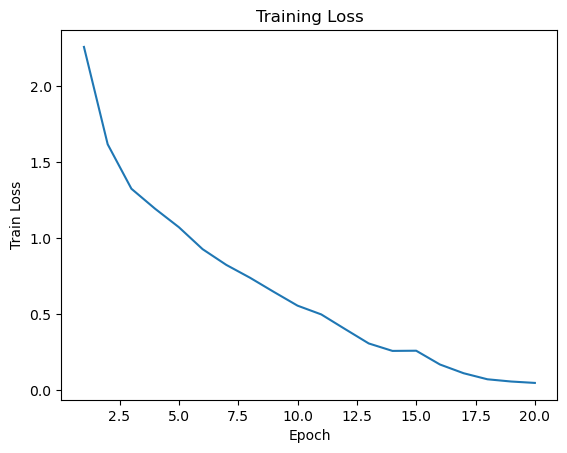

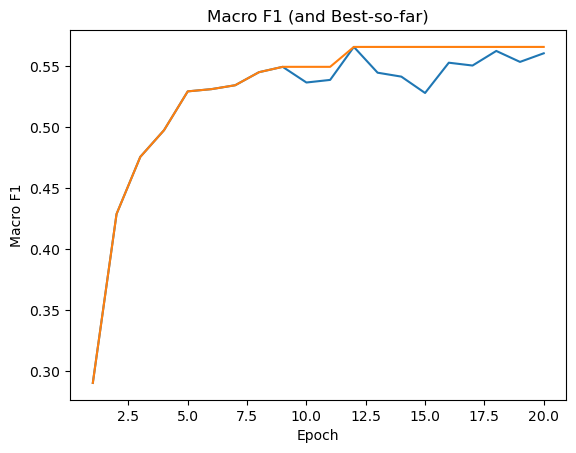

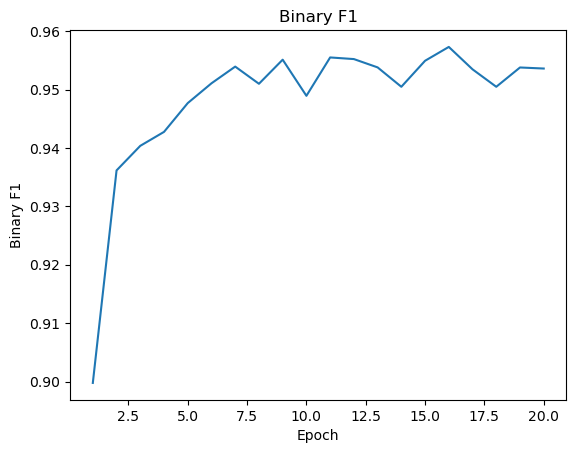

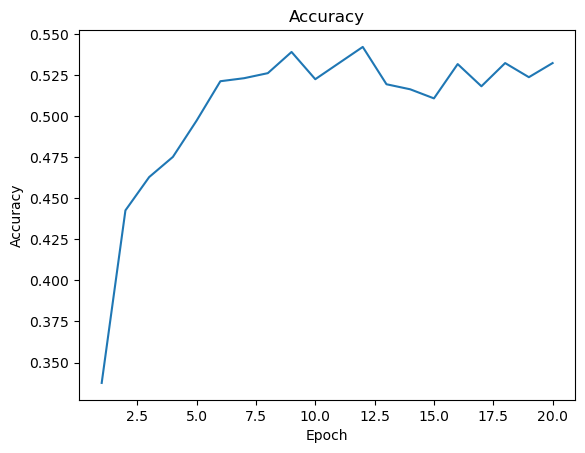

All plots saved successfully.


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

RESULT_DIR = REPO_ROOT / "results"
PLOTS_DIR = REPO_ROOT / "plots"/"Model 5 (Intermediate Fusion)"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    df_hist
except NameError:
    df_hist = pd.read_csv(RESULT_DIR / "model5_training_history.csv")

print("Saving plots to:", PLOTS_DIR)

# 1) Train Loss
plt.figure()
plt.plot(df_hist["epoch"], df_hist["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss")
plt.savefig(PLOTS_DIR / "model5_train_loss.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 2) Macro F1
plt.figure()
plt.plot(df_hist["epoch"], df_hist["macroF1"])
plt.plot(df_hist["epoch"], df_hist["best_macro_so_far"])
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 (and Best-so-far)")
plt.savefig(PLOTS_DIR / "model5_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 3) Binary F1
plt.figure()
plt.plot(df_hist["epoch"], df_hist["binaryF1"])
plt.xlabel("Epoch")
plt.ylabel("Binary F1")
plt.title("Binary F1")
plt.savefig(PLOTS_DIR / "model5_binary_f1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# 4) Accuracy
plt.figure()
plt.plot(df_hist["epoch"], df_hist["acc"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.savefig(PLOTS_DIR / "model5_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("All plots saved successfully.")
